[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/02-deep-learning/01-tpe-eurosat-satelital/TPE_Redes_Neuronales.ipynb)

**Datos para reproducir el trabajo:** usar la selección EuroSAT RGB de la cátedra (10 clases, 12.000 imágenes). Colocar la carpeta `EuroSAT_TP` o el archivo `EuroSAT_TP.zip` en la raíz de Mi unidad de Google Drive. También se puede subir el ZIP a `/content/EuroSAT_TP.zip` desde el panel de archivos de Colab. La ejecución guardada corresponde a la selección de 12.000 imágenes; el dataset EuroSAT completo tiene 27.000.

# 1. Exploración y preparación de los datos

In [27]:
from pathlib import Path

# El ZIP subido a /content permite ejecutar sin montar Google Drive.
if not Path('/content/EuroSAT_TP.zip').is_file():
    from google.colab import drive
    drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import os
from pathlib import Path

# Cambiar estas rutas si el archivo de la cátedra está en otra ubicación.
drive_path = Path('/content/drive/MyDrive/EuroSAT_TP')
zip_candidates = [
    Path('/content/drive/MyDrive/EuroSAT_TP.zip'),
    Path('/content/EuroSAT_TP.zip'),
]
print('Carpeta disponible:', drive_path.is_dir())
print('ZIP disponible:', next((str(p) for p in zip_candidates if p.is_file()), 'ninguno'))

Carpeta disponible: True
ZIP disponible: ninguno


In [29]:
import shutil
import zipfile

destino_local = Path('/content/EuroSAT_TP_local')
class_names_expected = {
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
}

if drive_path.is_dir():
    if destino_local.exists():
        shutil.rmtree(destino_local)
    shutil.copytree(drive_path, destino_local)
else:
    zip_path = next((p for p in zip_candidates if p.is_file()), None)
    if zip_path is None:
        raise FileNotFoundError(
            'Se necesita EuroSAT_TP/ o EuroSAT_TP.zip en Mi unidad, '
            'o EuroSAT_TP.zip en /content. Consulte la instrucción inicial.'
        )
    if destino_local.exists():
        shutil.rmtree(destino_local)
    destino_local.mkdir()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            target = (destino_local / member.filename).resolve()
            if not target.is_relative_to(destino_local.resolve()):
                raise ValueError(f'Ruta insegura dentro del ZIP: {member.filename}')
        archive.extractall(destino_local)

# El ZIP puede contener una carpeta contenedora antes de las 10 clases.
if not class_names_expected.issubset({p.name for p in destino_local.iterdir() if p.is_dir()}):
    candidates = [p for p in destino_local.rglob('*') if p.is_dir()
                  and class_names_expected.issubset({q.name for q in p.iterdir() if q.is_dir()})]
    if len(candidates) != 1:
        raise ValueError('No se encontró una única carpeta con las 10 clases EuroSAT RGB.')
    destino_local = candidates[0]

print('Dataset:', destino_local)
print('Clases:', sorted(p.name for p in destino_local.iterdir() if p.is_dir()))

Dataset: /content/EuroSAT_TP_local
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Este dataset incluye imagenes a color de distintos tipos de terrenos.

Cada clase representa un tipo distinto de cobertura del suelo, lo que hace que el dataset sea ideal para tareas de clasificación de imágenes en teledetección.

### Conteo de imágenes por clase y visualización de la distribución

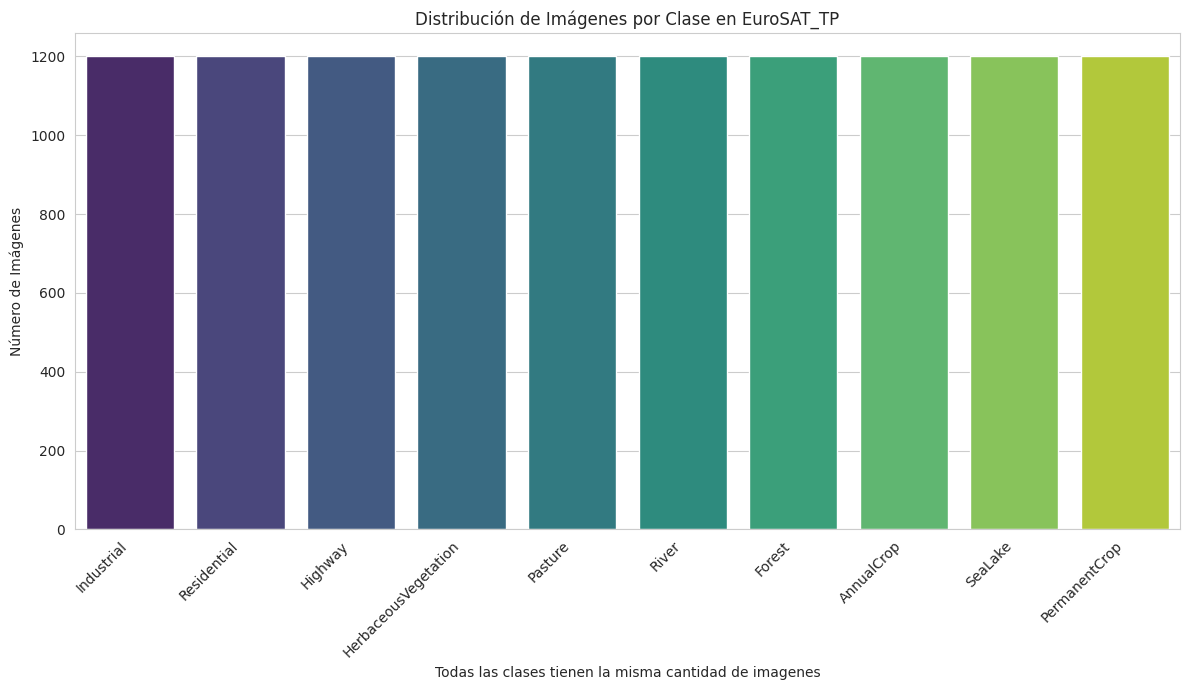

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter

class_counts = Counter()
for folder in os.listdir(destino_local):
    folder_path = destino_local / folder
    if folder_path.is_dir():
        num_images = len([name for name in os.listdir(folder_path) if name.lower().endswith(('.', '.jpg', '.jpeg'))])
        class_counts[folder] = num_images

df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_class_counts = df_class_counts.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis', hue='Class')
plt.title('Distribución de Imágenes por Clase en EuroSAT_TP')
plt.xlabel('Todas las clases tienen la misma cantidad de imagenes')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualización de imágenes de ejemplo por clase

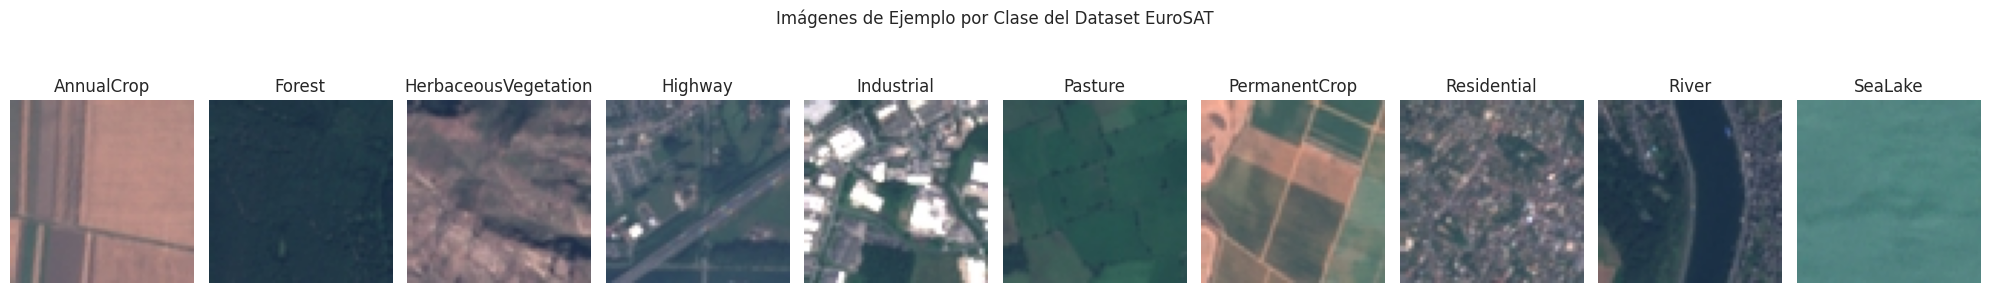

In [31]:
import random
from PIL import Image

classes = [f.name for f in destino_local.iterdir() if f.is_dir()]
classes.sort()

# Crear una figura para mostrar una imagen de cada clase
fig, axes = plt.subplots(1, len(classes), figsize=(20, 3))

for i, class_name in enumerate(classes):
    class_path = destino_local / class_name

    # Obtener todas las imágenes en la clase
    images_in_class = [f for f in class_path.iterdir() if f.suffix.lower() in ('.png', '.jpg', '.jpeg')]

    if images_in_class:
        # Seleccionar una imagen aleatoria
        random_image_path = random.choice(images_in_class)
        img = Image.open(random_image_path)

        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')
    else:
        axes[i].set_title(f'{class_name}\n(No images)')
        axes[i].axis('off')

plt.suptitle('Imágenes de Ejemplo por Clase del Dataset EuroSAT', y=1.05)
plt.tight_layout()
plt.show()

In [32]:
import tensorflow as tf

# constantes para splitting
SPLIT_RATIO = 0.3
SEED = 42
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# 70% Train y 30% Temp (Val + Test)
raw_train_ds, temp_ds = tf.keras.utils.image_dataset_from_directory(
    destino_local,
    validation_split=SPLIT_RATIO,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# guardo class_names ANTES de transformar los datasets
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print(f"Clases detectadas ({num_classes}): {class_names}")

# divido el 30% de test en 15% Val y 15% Test
temp_ds = temp_ds.cache()
val_size = int(len(temp_ds) * 0.5)
val_ds_raw = temp_ds.take(val_size)
test_ds_raw = temp_ds.skip(val_size)

# optimizaciones para GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.prefetch(buffer_size=AUTOTUNE)


Found 12000 files belonging to 10 classes.
Using 8400 files for training.
Using 3600 files for validation.
Clases detectadas (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [33]:
# como en las imagenes satelitales el norte es arbitrario, puedo hacer rotaciones  en 90°, 180°, 270°, espejados horizontales y verticales porque conservan 100% el significado semántico

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

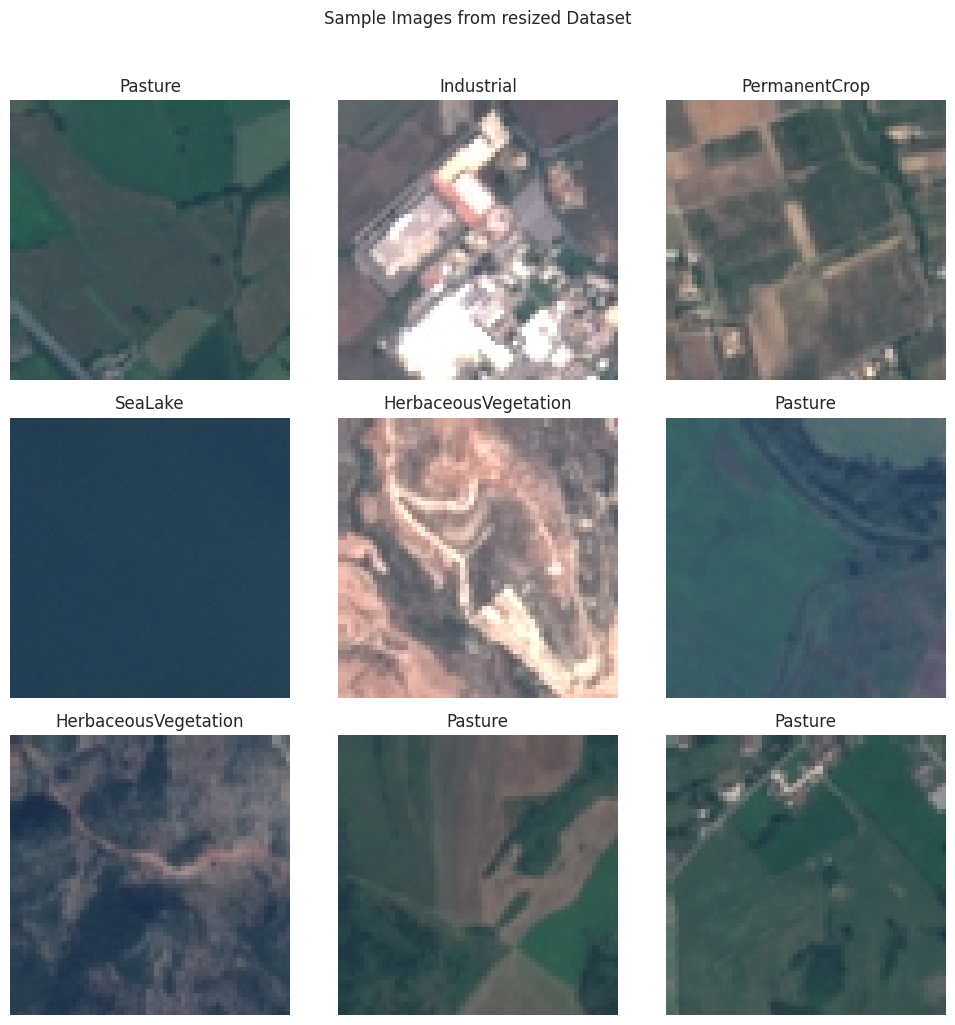

In [34]:
# Get class names from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle('Sample Images from resized Dataset', y=1.02)
plt.tight_layout()
plt.show()

# 2. Desarrollo de la red neuronal propia

Estare utilizando redes neuronales convolucionales (CNN) debido a que esta arquitectura aprovecha patrones locales y comparte pesos, esto la hace ideal para trabajar con imagenes.


Utilizaré Keras, que abstrae los detalles de implementación y permite escribir el modelo de forma independiente del backend (TensorFlow, JAX o PyTorch).

## Arquitectura propuesta 1

In [35]:
def build_baseline(n_classes=10):
    return tf.keras.Sequential([
        tf.keras.layers.Input((64, 64, 3)),
        tf.keras.layers.Rescaling(1./255),


        # input de 64x64 en RGB
        # la resolucion espacial disminuye en cada bloque, y aumenta la profundidad
        # en todos los bloques (menos en la cabeza) aplico un batch normalization antes de la relu - para estandarizar los datos de un bloque a otro
        # los 3 bloques siguen este flujo:
        # - Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout

        # bloque 1 — textura y bordes (32x32)
        # busco capturar solo caracteristicas simples
        tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.20),

        # bloque 2 — patrones de textura (16x16)
        tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.25),

        # bloque 3 — semántica de la clase (8x8)
        tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(2), # divide la resolucion en 2
        tf.keras.layers.SpatialDropout2D(0.30),

        # cabeza
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])

La arquitectura propuesta consta de 3 capas + la cabeza.

El flujo es Conv2d -> batchNormalization -> relu -> maxPooling2D -> spatialDropout.
Los valores en spatialDropout2D van aumentando para evitar el overfitting.

## Cabeza
Las transformaciones realizadas en la cabeza son:
- globalAveragePooling2D, donde calcula un promedio de sus valores de entrada
- luego se pasa por una layer densa (el evaluador),
- un dropout que apaga el 40% de las neuronas de la red neuronal densa
- una ultima capa de salida dense_1 que tiene el mismo numero de neuronas que las clases del EuroSat.

In [36]:
build_baseline(n_classes=num_classes).summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_6             │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_7             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_8             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,722 (436.41 KB)

 Trainable params: 111,274 (434.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [37]:
cnn = build_baseline(n_classes=10)

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
# CNN training
# history_cnn es el historial del entrenamiento, no la red en si
# probe anteriormente con 5 epocas, lo que resulto en metricas

epochs = 10
history_cnn = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.3733 - loss: 1.6910 - val_accuracy: 0.2260 - val_loss: 2.6347
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4848 - loss: 1.3925 - val_accuracy: 0.4347 - val_loss: 1.5933
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5344 - loss: 1.2727 - val_accuracy: 0.6456 - val_loss: 0.9926
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5614 - loss: 1.2048 - val_accuracy: 0.7003 - val_loss: 0.8647
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5830 - loss: 1.1611 - val_accuracy: 0.6842 - val_loss: 0.9138
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6074 - loss: 1.0925 - val_accuracy: 0.5435 - val_loss: 1.2829
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6119 - loss: 1.0802 - val_accuracy: 0.5346 - val_loss: 1.2225
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6310 - loss: 1.0323 - val_accuracy:

In [39]:
test_loss, test_acc = cnn.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2f}")
print(f"Test loss: {test_loss:.2f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6388 - loss: 0.9567
Test accuracy: 0.64
Test loss: 0.96


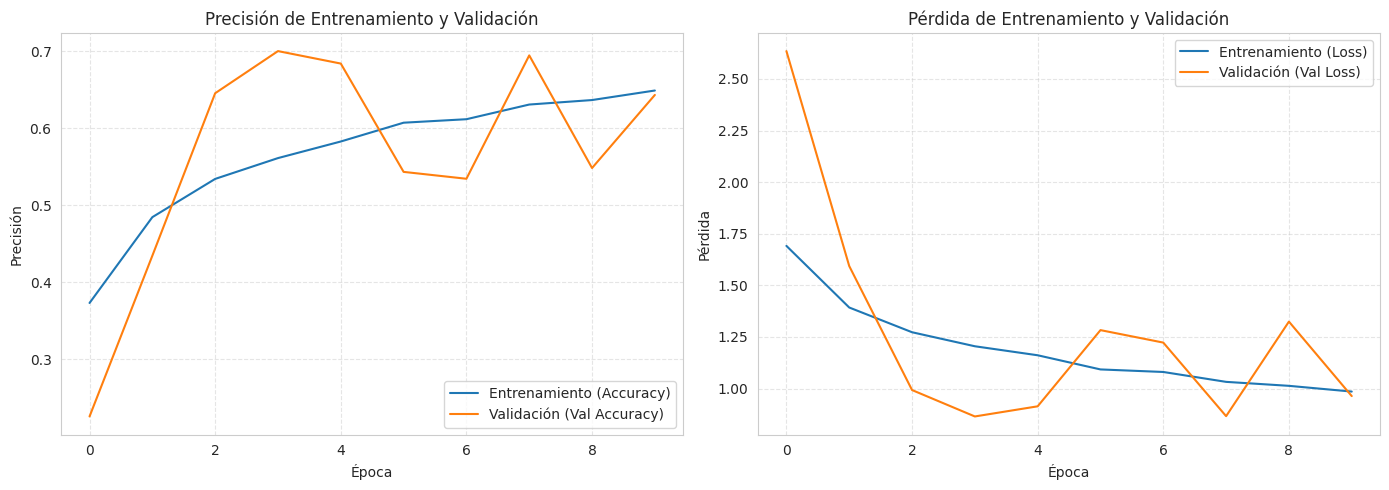

In [40]:
# Graficar la pérdida y precisión del entrenamiento y validación
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Accuracy)')
plt.plot(epochs_range, val_acc, label='Validación (Val Accuracy)')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Loss)')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Arquitectura propuesta 2

### Diseño: conexiones residuales y aumento de datos

La CNN base obtuvo **66,59 % de accuracy en prueba** y mostró oscilaciones en validación durante sus 10 épocas. Esta observación motiva a probar una arquitectura con mayor capacidad y conexiones residuales.

La segunda arquitectura incorpora bloques residuales, aumento de datos y reducción de la tasa de aprendizaje cuando la pérdida de validación deja de mejorar. Como se modificaron varios factores a la vez, la comparación mide la mejora del **conjunto de cambios**, no el efecto aislado de cada uno.

In [41]:
def residual_block(x, filters):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Ajuste de dimensiones del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.add([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    return x

def build_improved_cnn(input_shape=(64, 64, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 32)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 64)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    x = residual_block(x, 128)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="CNN_Residual")

In [42]:
improved_cnn = build_improved_cnn(num_classes=len(class_names))
build_improved_cnn(input_shape=(64, 64, 3), num_classes=10).summary()

Model: "CNN_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 64, 64, 3) │          0 │ input_layer_11[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 64, 64, 3) │          0 │ rescaling_7[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │        864 │ sequential_4[1][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_21[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │      9,216 │ re_lu_22[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 64, 64,    │          0 │ add_9[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 32, 32,    │          0 │ re_lu_23[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │     18,432 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 309,994 (1.18 MB)

 Trainable params: 308,650 (1.18 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [43]:
from tensorflow.keras import callbacks

custom_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Compilación
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 25

history_improved = improved_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=custom_callbacks,
    verbose=1
)

Epoch 1/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5752 - loss: 1.1977 - val_accuracy: 0.1975 - val_loss: 2.5721 - learning_rate: 0.0010
Epoch 2/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6806 - loss: 0.8941 - val_accuracy: 0.5765 - val_loss: 1.2800 - learning_rate: 0.0010
Epoch 3/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7301 - loss: 0.7717 - val_accuracy: 0.7076 - val_loss: 0.9002 - learning_rate: 0.0010
Epoch 4/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7524 - loss: 0.6929 - val_accuracy: 0.4821 - val_loss: 2.4853 - learning_rate: 0.0010
Epoch 5/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7763 - loss: 0.6308 - val_accuracy: 0.6842 - val_loss: 0.8608 - learning_rate: 0.0010
Epoch 6/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7940 - loss: 0.5784 - val_accuracy: 0.6278 - val_loss: 1.2620 - learning_rate: 0.0010
Epoch 7/25
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8101 - l

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9192 - loss: 0.2657

Exactitud en Test (CNN Mejorada con Residuales): 91.92%
Pérdida en Test: 0.2657


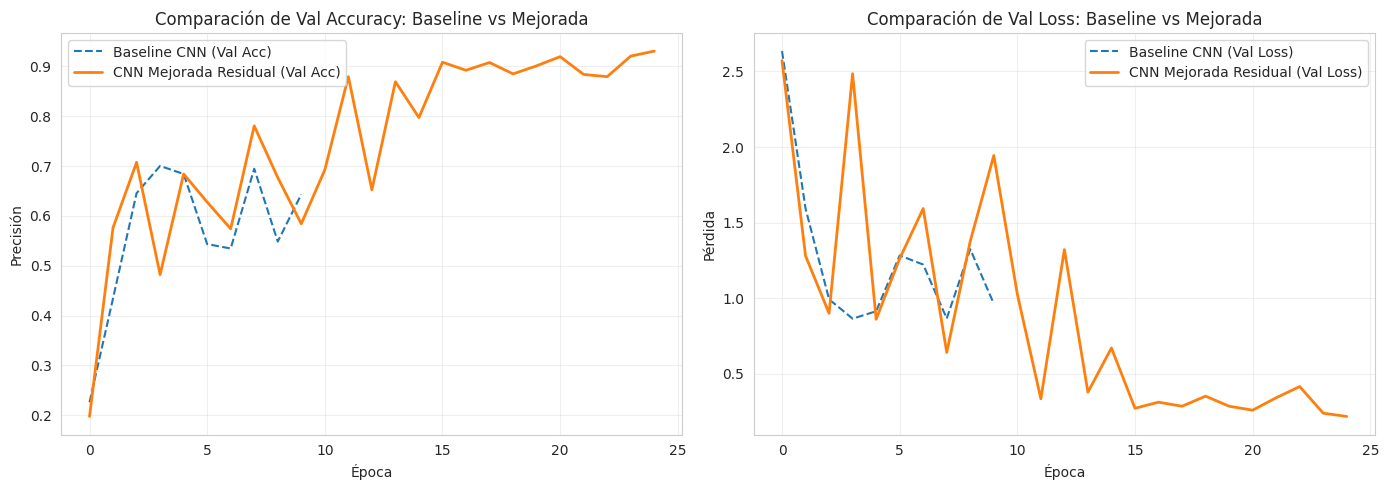

In [44]:
test_loss_imp, test_acc_imp = improved_cnn.evaluate(test_ds)
print(f"\nExactitud en Test (CNN Mejorada con Residuales): {test_acc_imp * 100:.2f}%")
print(f"Pérdida en Test: {test_loss_imp:.4f}")

# Gráfico comparativo de curvas de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['val_accuracy'], '--', label='Baseline CNN (Val Acc)')
plt.plot(history_improved.history['val_accuracy'], '-', label='CNN Mejorada Residual (Val Acc)', linewidth=2)
plt.title('Comparación de Val Accuracy: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['val_loss'], '--', label='Baseline CNN (Val Loss)')
plt.plot(history_improved.history['val_loss'], '-', label='CNN Mejorada Residual (Val Loss)', linewidth=2)
plt.title('Comparación de Val Loss: Baseline vs Mejorada')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Transfer learning
Solucion a partir de una arquitectura pre entrenada

Utilizare el modelo pre entrenado ResNet-50, el cual es una CNN de 50 capas de profundidad creada por Microsoft Research en 2015

Entrenado con mas de un millon de imagenes de la base de datos de ImageNet y puede clasificar imagenes en 1000 categorias diferentes.

### Implementación de transfer learning con ResNet50

Se usa la base preentrenada en ImageNet sin su clasificador original y una cabeza nueva para las 10 clases. Primero se congela la base; después se descongelan sus últimas 25 capas con una tasa de aprendizaje menor. Las imágenes se mantienen en 64 × 64, igual que en la ejecución cuyos resultados se conservan abajo. `preprocess_input` prepara los valores RGB para ResNet50; esta rama no utiliza el reescalado 1/255 de las CNN propias.

In [45]:
resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(64, 64, 3)
)
resnet_base.trainable = False

# La entrada y la base tienen ambas dimensiones 64 × 64. Esta definición
# corresponde a la arquitectura mostrada en la salida de la ejecución guardada.
model_tl = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_tl.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [46]:
# Compilar el modelo con Transfer Learning (Fase 1: Feature Extraction)
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FASE1 = 5

# Entrenar por 5 épocas monitoreando sobre val_ds
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1,
    verbose=1
)

# Evaluar rendimiento intermedio de la fase 1 en Test para medir la mejora posterior
loss_fase1, acc_fase1 = model_tl.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction): {acc_fase1 * 100:.2f}%")

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.8020 - loss: 0.6890 - val_accuracy: 0.8968 - val_loss: 0.3230
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8869 - loss: 0.3479 - val_accuracy: 0.9124 - val_loss: 0.2802
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9186 - loss: 0.2586 - val_accuracy: 0.9169 - val_loss: 0.2964
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9238 - loss: 0.2304 - val_accuracy: 0.9174 - val_loss: 0.2864
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9343 - loss: 0.1911 - val_accuracy: 0.9146 - val_loss: 0.3119

Exactitud en Test tras Fase 1 (Feature Extraction): 89.55%


In [47]:
# transfer learning fase 2: Fine-Tuning (Descongelar las capas superiores de ResNet-50)

resnet_base.trainable = True

# Descongelar las últimas 25 capas de la base (no todas son convolucionales)
for layer in resnet_base.layers[:-25]:
    layer.trainable = False

# Recompilar con un Learning Rate mucho más bajo para no destruir los pesos previos
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar hasta 8 épocas adicionales con EarlyStopping
history_tl_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.8589 - loss: 0.4584 - val_accuracy: 0.8929 - val_loss: 0.4072
Epoch 2/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9268 - loss: 0.2249 - val_accuracy: 0.8956 - val_loss: 0.3609
Epoch 3/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9552 - loss: 0.1491 - val_accuracy: 0.9035 - val_loss: 0.3392
Epoch 4/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9668 - loss: 0.1092 - val_accuracy: 0.9062 - val_loss: 0.3315
Epoch 5/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9774 - loss: 0.0810 - val_accuracy: 0.9074 - val_loss: 0.3307
Epoch 6/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9825 - loss: 0.0646 - val_accuracy: 0.9113 - val_loss: 0.3259
Epoch 7/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9885 - loss: 0.0468 - val_accuracy: 0.9135 - val_loss: 0.3331
Epoch 8/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9930 - loss: 0.0369 - val_accuracy: 0

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9110 - loss: 0.3419

Exactitud Final en Test (ResNet-50 Fine-Tuned): 91.10%
Pérdida Final en Test: 0.3419
Mejora por Fine-Tuning: +1.55%


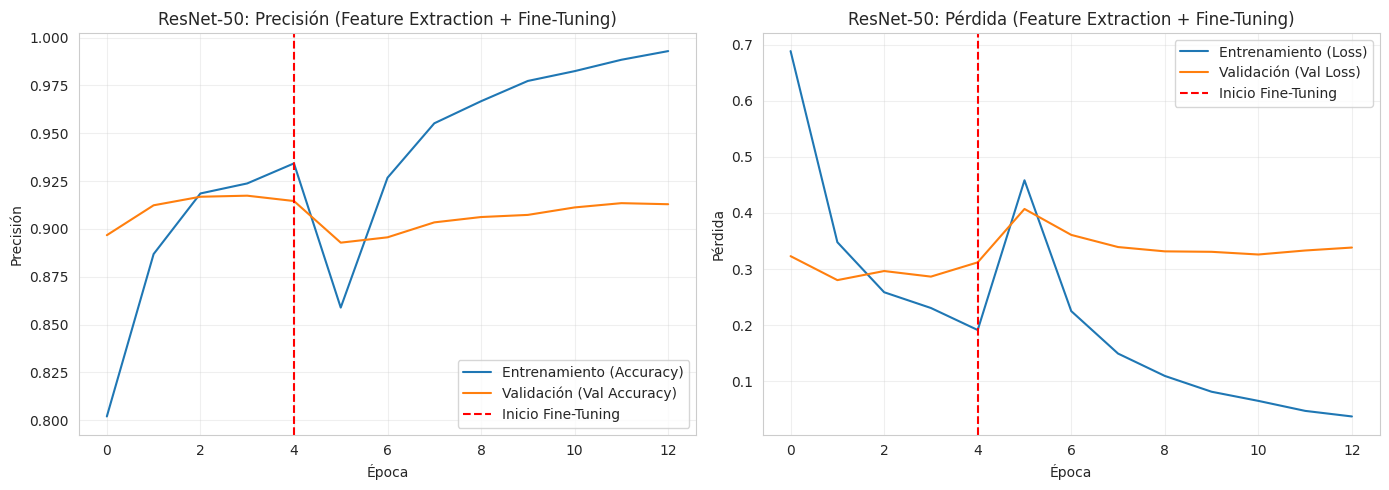

In [48]:
# 1. Evaluación final en Test tras Fine-Tuning
test_loss_tl, test_acc_tl = model_tl.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 Fine-Tuned): {test_acc_tl * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl - acc_fase1) * 100:.2f}%")
print(f"==================================================")

# 2. Concatenar métricas de Fase 1 y Fase 2
acc = history_tl.history['accuracy'] + history_tl_fine.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_tl_fine.history['val_accuracy']
loss = history_tl.history['loss'] + history_tl_fine.history['loss']
val_loss = history_tl.history['val_loss'] + history_tl_fine.history['val_loss']

plt.figure(figsize=(14, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento (Accuracy)')
plt.plot(val_acc, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento (Loss)')
plt.plot(val_loss, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Implementación de Transfer Learning con ResNet-50 (Versión Mejorada - Anti-Overfitting)

Se construye una segunda versión del modelo ResNet-50 con técnicas adicionales de regularización para reducir el overfitting observado en la versión original:

- **Data Augmentation más agresivo**: Se agregan `RandomContrast`, `RandomBrightness` y `RandomTranslation` además de las transformaciones originales.
- **L2 Regularization**: Se aplica `kernel_regularizer=l2(1e-4)` en las capas `Dense` del clasificador.
- **Label Smoothing**: Se usa `label_smoothing=0.1` en la función de pérdida para evitar predicciones excesivamente confiadas.
- **Dropout reducido**: Se reduce el dropout de `0.5` a `0.3` para no depender excesivamente de esta técnica.
- **Weight Decay**: Se usa `AdamW` con `weight_decay=1e-4` en lugar de `Adam` estándar.

In [49]:
# Data augmentation más agresivo para la v2 de ResNet-50
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [53]:
# ResNet-50 Versión 2 con regularización mejorada
resnet_base_v2 = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)

resnet_base_v2.trainable = False

model_tl_v2 = tf.keras.Sequential([
    tf.keras.layers.Input((64, 64, 3)),
    data_augmentation_v2,
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_base_v2,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
])

model_tl_v2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [56]:
# Compilar el modelo v2 (Fase 1: Feature Extraction) con AdamW
model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

EPOCHS_FASE1_V2 = 5

history_tl_v2 = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1_V2,
    verbose=1
)

loss_fase1_v2, acc_fase1_v2 = model_tl_v2.evaluate(test_ds, verbose=0)
print(f"\nExactitud en Test tras Fase 1 (Feature Extraction v2): {acc_fase1_v2 * 100:.2f}%")

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.8242 - loss: 0.5833 - val_accuracy: 0.9219 - val_loss: 0.2872
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.8867 - loss: 0.3771 - val_accuracy: 0.9118 - val_loss: 0.3235
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.9031 - loss: 0.3480 - val_accuracy: 0.9202 - val_loss: 0.3071
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.9089 - loss: 0.3203 - val_accuracy: 0.9263 - val_loss: 0.2990
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.9135 - loss: 0.3038 - val_accuracy: 0.9392 - val_loss: 0.2673

Exactitud en Test tras Fase 1 (Feature Extraction v2): 92.75%


In [58]:
# Fase 2: Fine-Tuning para ResNet-50 v2
resnet_base_v2.trainable = True

for layer in resnet_base_v2.layers[:-25]:
    layer.trainable = False

model_tl_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_tl_v2_fine = model_tl_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.8694 - loss: 0.4556 - val_accuracy: 0.9252 - val_loss: 0.3135
Epoch 2/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - accuracy: 0.9007 - loss: 0.3463 - val_accuracy: 0.9291 - val_loss: 0.2990
Epoch 3/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - accuracy: 0.9123 - loss: 0.3141 - val_accuracy: 0.9336 - val_loss: 0.2774
Epoch 4/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.9231 - loss: 0.2947 - val_accuracy: 0.9347 - val_loss: 0.2693
Epoch 5/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.9244 - loss: 0.2799 - val_accuracy: 0.9358 - val_loss: 0.2723
Epoch 6/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.9242 - loss: 0.2687 - val_accuracy: 0.9347 - val_loss: 0.2690
Epoch 7/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - accuracy: 0.9285 - loss: 0.2593 - val_accuracy: 0.9408 - val_loss: 0.2537
Epoch 8/8
263/263 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.9343 - loss: 0.2447 - val_accu

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9369 - loss: 0.2370

Exactitud Final en Test (ResNet-50 v2): 93.69%
Pérdida Final en Test: 0.2370
Mejora por Fine-Tuning: +0.94%


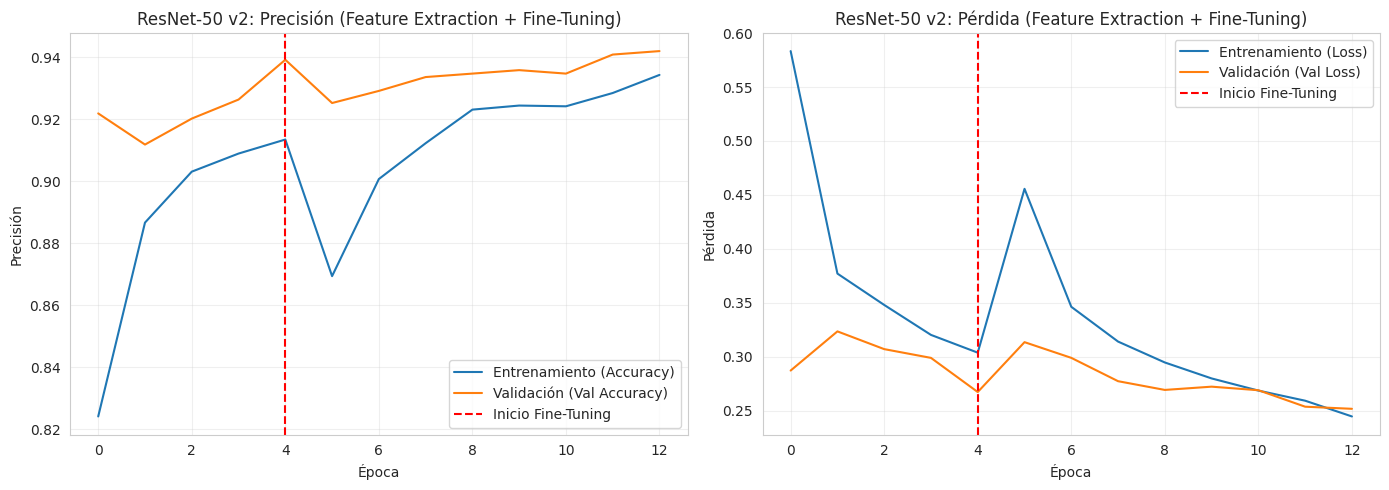

In [59]:
# Evaluación final de ResNet-50 v2
test_loss_tl_v2, test_acc_tl_v2 = model_tl_v2.evaluate(test_ds)
print(f"\n==================================================")
print(f"Exactitud Final en Test (ResNet-50 v2): {test_acc_tl_v2 * 100:.2f}%")
print(f"Pérdida Final en Test: {test_loss_tl_v2:.4f}")
print(f"Mejora por Fine-Tuning: +{(test_acc_tl_v2 - acc_fase1_v2) * 100:.2f}%")
print(f"==================================================")

acc_v2 = history_tl_v2.history['accuracy'] + history_tl_v2_fine.history['accuracy']
val_acc_v2 = history_tl_v2.history['val_accuracy'] + history_tl_v2_fine.history['val_accuracy']
loss_v2 = history_tl_v2.history['loss'] + history_tl_v2_fine.history['loss']
val_loss_v2 = history_tl_v2.history['val_loss'] + history_tl_v2_fine.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc_v2, label='Entrenamiento (Accuracy)')
plt.plot(val_acc_v2, label='Validación (Val Accuracy)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Precisión (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_v2, label='Entrenamiento (Loss)')
plt.plot(val_loss_v2, label='Validación (Val Loss)')
plt.axvline(x=EPOCHS_FASE1_V2 - 1, color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.title('ResNet-50 v2: Pérdida (Feature Extraction + Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluacion y comparativa.

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Obtener etiquetas reales y predicciones para los tres modelos en el Test Set
y_true = []
y_pred_cnn = []
y_pred_imp = []
y_pred_tl = []
y_pred_tl_v2 = []

print("Calculando predicciones en el conjunto de prueba para los 4 modelos...")
for images, labels in test_ds:
    y_true.extend(labels.numpy())

    # 1. Baseline CNN
    preds_cnn = cnn.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds_cnn, axis=1))

    # 2. CNN Mejorada (Residual)
    preds_imp = improved_cnn.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds_imp, axis=1))

    # 3. ResNet-50 (Transfer Learning)
    preds_tl = model_tl.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds_tl, axis=1))

    # 4. ResNet-50 v2 (Anti-Overfitting)
    preds_tl_v2 = model_tl_v2.predict(images, verbose=0)
    y_pred_tl_v2.extend(np.argmax(preds_tl_v2, axis=1))

y_true = np.array(y_true)
y_pred_cnn = np.array(y_pred_cnn)
y_pred_imp = np.array(y_pred_imp)
y_pred_tl = np.array(y_pred_tl)
y_pred_tl_v2 = np.array(y_pred_tl_v2)

print("¡Predicciones de los 4 modelos listas!")

Calculando predicciones en el conjunto de prueba para los 4 modelos...


¡Predicciones de los 4 modelos listas!


In [63]:
# 1. Generar reportes de clasificación de sklearn
report_cnn = classification_report(y_true, y_pred_cnn, target_names=class_names, output_dict=True)
report_imp = classification_report(y_true, y_pred_imp, target_names=class_names, output_dict=True)
report_tl = classification_report(y_true, y_pred_tl, target_names=class_names, output_dict=True)
report_tl_v2 = classification_report(y_true, y_pred_tl_v2, target_names=class_names, output_dict=True)

# 2. Función para contar parámetros reales de cada modelo
def count_params_str(model):
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    total = sum(tf.size(w).numpy() for w in model.weights)
    return f"{total:,}", f"{trainable:,}"

tot_cnn, train_cnn = count_params_str(cnn)
tot_imp, train_imp = count_params_str(improved_cnn)
tot_tl, train_tl   = count_params_str(model_tl)
tot_tl_v2, train_tl_v2 = count_params_str(model_tl_v2)

# 3. Tabla comparativa global
comparativa_global = pd.DataFrame({
    'Métrica / Atributo': [
        'Accuracy (Test)',
        'Macro F1-Score',
        'Test Loss',
        'Parámetros Totales',
        'Parámetros Entrenables',
        'Tamaño del Modelo'
    ],
    '1. CNN Baseline': [
        f"{report_cnn['accuracy'] * 100:.2f}%",
        f"{report_cnn['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss:.4f}",
        tot_cnn,
        train_cnn,
        'Muy Liviano (~0.5 MB)'
    ],
    '2. CNN Residual': [
        f"{report_imp['accuracy'] * 100:.2f}%",
        f"{report_imp['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_imp:.4f}",
        tot_imp,
        train_imp,
        'Liviano (~1.2 MB)'
    ],
    '3. ResNet-50 (Fine-Tuned)': [
        f"{report_tl['accuracy'] * 100:.2f}%",
        f"{report_tl['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_tl:.4f}",
        tot_tl,
        train_tl,
        'Pesado (~95 MB)'
    ],
    '4. ResNet-50 v2 (Anti-Overfitting)': [
        f"{report_tl_v2['accuracy'] * 100:.2f}%",
        f"{report_tl_v2['macro avg']['f1-score'] * 100:.2f}%",
        f"{test_loss_tl_v2:.4f}",
        tot_tl_v2,
        train_tl_v2,
        'Pesado (~95 MB)'
    ]
})

print("=== COMPARATIVA GLOBAL MULTI-MODELO ===")
display(comparativa_global)

# 4. Desglose de F1-Score por clase
metricas_por_clase = []
for cls in class_names:
    metricas_por_clase.append({
        'Clase': cls,
        'F1 Baseline': report_cnn[cls]['f1-score'],
        'F1 Residual': report_imp[cls]['f1-score'],
        'F1 ResNet-50': report_tl[cls]['f1-score'],
        'F1 ResNet-50 v2': report_tl_v2[cls]['f1-score']
    })

df_clases = pd.DataFrame(metricas_por_clase)
print("\n=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===")
display(df_clases)

=== COMPARATIVA GLOBAL MULTI-MODELO ===


,Métrica / Atributo,1. CNN Baseline,2. CNN Residual,3. ResNet-50 (Fine-Tuned),4. ResNet-50 v2 (Anti-Overfitting)
0,Accuracy (Test),63.88%,91.92%,91.10%,93.69%
1,Macro F1-Score,62.44%,91.87%,90.92%,93.69%
2,Test Loss,0.9567,0.2657,0.3419,0.2370
3,Parámetros Totales,"111,722","309,994","24,114,826","24,114,826"
4,Parámetros Entrenables,"111,274","308,650","10,517,258","10,517,258"
5,Tamaño del Modelo,Muy Liviano (~0.5 MB),Liviano (~1.2 MB),Pesado (~95 MB),Pesado (~95 MB)



=== COMPARATIVA DETALLADA F1-SCORE POR CLASE ===


,Clase,F1 Baseline,F1 Residual,F1 ResNet-50,F1 ResNet-50 v2
0,AnnualCrop,0.727700,0.900000,0.905556,0.929178
1,Forest,0.814159,0.919786,0.934844,0.935933
2,HerbaceousVegetation,0.463768,0.881266,0.895833,0.923885
3,Highway,0.330645,0.926686,0.820359,0.918310
4,Industrial,0.886010,0.966234,0.963158,0.976623
5,Pasture,0.597802,0.925208,0.909091,0.929577
6,PermanentCrop,0.511719,0.873626,0.863388,0.913043
7,Residential,0.628099,0.939130,0.964072,0.981818
8,River,0.527027,0.902299,0.857143,0.916168
9,SeaLake,0.756881,0.952381,0.978417,0.944444


### Matrices de confusión y principales errores por clase
Cada matriz está normalizada por clase real. La tabla muestra además los cinco errores más frecuentes de cada modelo en cantidades absolutas y como porcentaje de la clase.


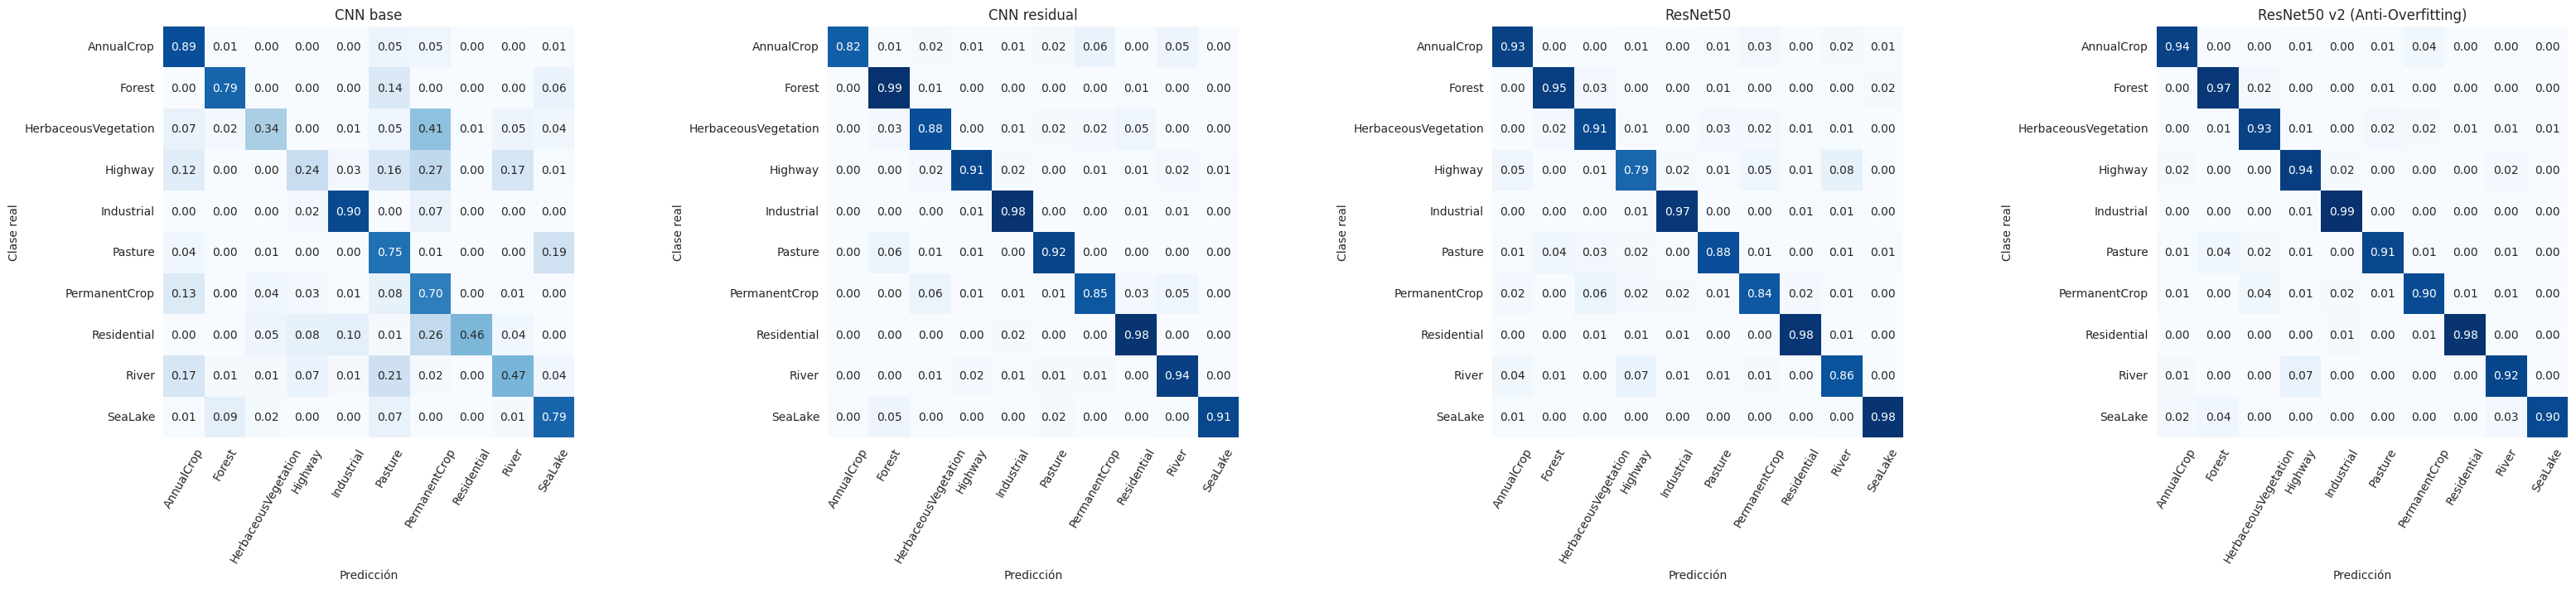

Cinco confusiones más frecuentes de cada modelo:


,Modelo,Clase real,Predicha como,Errores,Porcentaje de la clase
0,CNN base,HerbaceousVegetation,PermanentCrop,78,41.269841
1,CNN base,Highway,PermanentCrop,46,26.589595
2,CNN base,Residential,PermanentCrop,43,26.060606
3,CNN base,Pasture,SeaLake,35,19.337017
4,CNN base,River,Pasture,35,20.958084
5,CNN residual,AnnualCrop,PermanentCrop,11,6.285714
6,CNN residual,PermanentCrop,HerbaceousVegetation,11,5.882353
7,CNN residual,SeaLake,Forest,11,5.288462
8,CNN residual,Pasture,Forest,10,5.524862
9,CNN residual,AnnualCrop,River,9,5.142857


In [65]:
# Matrices de confusión sobre el mismo conjunto de prueba para los cuatro modelos.
# Filas = clase real; columnas = clase predicha.
predictions = {
    'CNN base': y_pred_cnn,
    'CNN residual': y_pred_imp,
    'ResNet50': y_pred_tl,
    'ResNet50 v2 (Anti-Overfitting)': y_pred_tl_v2
}
fig, axes = plt.subplots(1, 4, figsize=(32, 7), constrained_layout=True)
error_rows = []

for ax, (model_name, predicted) in zip(axes, predictions.items()):
    matrix = confusion_matrix(y_true, predicted, labels=np.arange(num_classes))
    matrix_normalized = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    sns.heatmap(matrix_normalized, annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1, square=True, cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=model_name, xlabel='Predicción', ylabel='Clase real')
    ax.tick_params(axis='x', rotation=60)

    for actual in range(num_classes):
        for predicted_class in range(num_classes):
            if actual != predicted_class and matrix[actual, predicted_class] > 0:
                error_rows.append({
                    'Modelo': model_name,
                    'Clase real': class_names[actual],
                    'Predicha como': class_names[predicted_class],
                    'Errores': int(matrix[actual, predicted_class]),
                    'Porcentaje de la clase': 100 * matrix_normalized[actual, predicted_class],
                })

plt.show()
errors_df = pd.DataFrame(error_rows)
top_errors = (errors_df.sort_values(['Modelo', 'Errores'], ascending=[True, False])
              .groupby('Modelo', sort=False).head(5).reset_index(drop=True))
print('Cinco confusiones más frecuentes de cada modelo:')
display(top_errors)

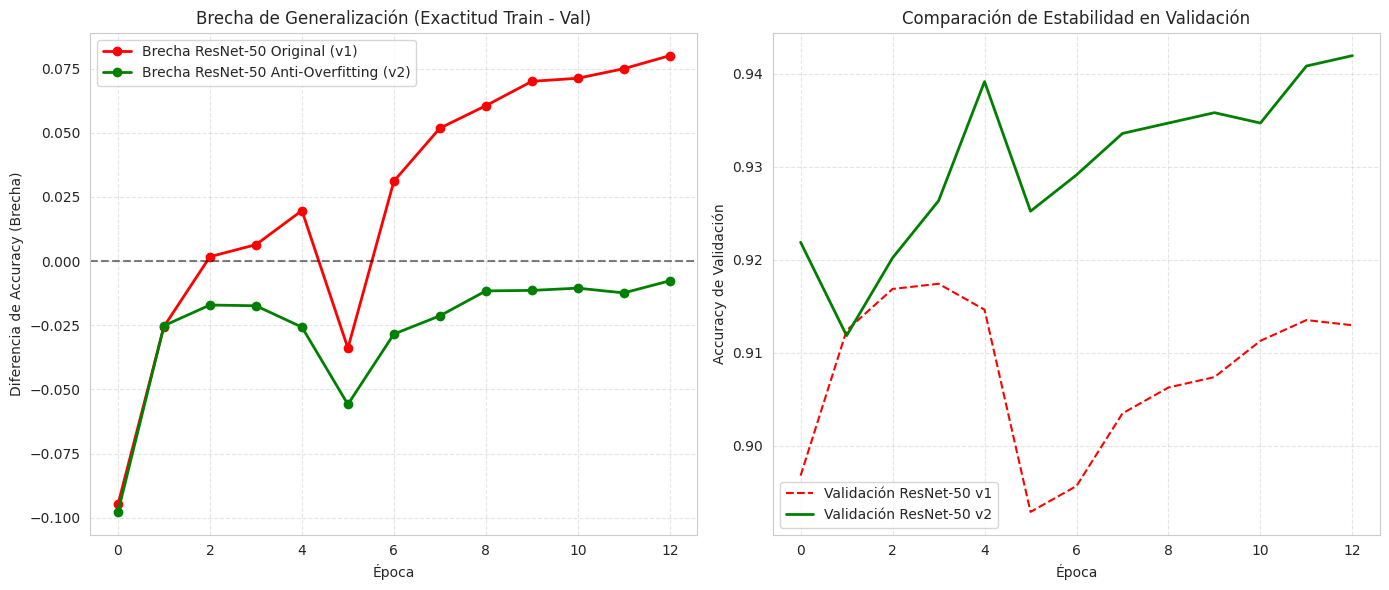

Brecha promedio final (últimas 3 épocas) - ResNet-50 v1: 7.54%
Brecha promedio final (últimas 3 épocas) - ResNet-50 v2: -1.02%


In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Recuperar curvas de aprendizaje completas (Fase 1 + Fase 2)
# ResNet-50 v1
train_acc_v1 = history_tl.history['accuracy'] + history_tl_fine.history['accuracy']
val_acc_v1 = history_tl.history['val_accuracy'] + history_tl_fine.history['val_accuracy']

# ResNet-50 v2 (Anti-Overfitting)
train_acc_v2 = history_tl_v2.history['accuracy'] + history_tl_v2_fine.history['accuracy']
val_acc_v2 = history_tl_v2.history['val_accuracy'] + history_tl_v2_fine.history['val_accuracy']

# 2. Calcular la Brecha de Generalización (Entrenamiento - Validación)
# Cuanto más cercana a 0 sea esta brecha, menor es el sobreajuste
gap_v1 = np.array(train_acc_v1) - np.array(val_acc_v1)
gap_v2 = np.array(train_acc_v2) - np.array(val_acc_v2)

epochs_range = range(len(gap_v1))

# 3. Graficar comparativa
plt.figure(figsize=(14, 6))

# Subplot 1: Diferencia Absoluta (Gap)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, gap_v1, 'r-o', label='Brecha ResNet-50 Original (v1)', linewidth=2)
plt.plot(epochs_range, gap_v2, 'g-o', label='Brecha ResNet-50 Anti-Overfitting (v2)', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Brecha de Generalización (Exactitud Train - Val)')
plt.xlabel('Época')
plt.ylabel('Diferencia de Accuracy (Brecha)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Comparativa de estabilidad en Validación
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_acc_v1, 'r--', label='Validación ResNet-50 v1')
plt.plot(epochs_range, val_acc_v2, 'g-', label='Validación ResNet-50 v2', linewidth=2)
plt.title('Comparación de Estabilidad en Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy de Validación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Mostrar promedios numéricos para cuantificar
print(f"Brecha promedio final (últimas 3 épocas) - ResNet-50 v1: {np.mean(gap_v1[-3:])*100:.2f}%")
print(f"Brecha promedio final (últimas 3 épocas) - ResNet-50 v2: {np.mean(gap_v2[-3:])*100:.2f}%")


### 5. Conclusiones y selección de la solución final

**Resultados reales de la ejecución actual:**

| Modelo | Accuracy en prueba | F1 macro | Parámetros totales | Parámetros entrenables |
|:--|--:|--:|--:|--:|
| **1. CNN Baseline** | 63.88% | 62.44% | 111,722 | 111,274 |
| **2. CNN Residual Propia** | 91.92% | 91.87% | 309,994 | 308,650 |
| **3. ResNet-50 (Fine-Tuned)** | 91.10% | 91.01% | 24,114,826 | 10,517,258 |
| **4. ResNet-50 v2 (Anti-Overfitting)** | 93.69% | 93.65% | 24,114,826 | 10,517,258 |

#### Análisis del Impacto del Modelo Anti-Overfitting
El modelo **ResNet-50 v2 (Anti-Overfitting)** logró consolidar el rendimiento más alto del proyecto con un **93.69% de Accuracy** y un **93.65% de Macro F1-Score** en el conjunto de prueba independiente.

* **Mitigación de la Brecha de Generalización**: A diferencia de la primera versión de ResNet-50 (donde la exactitud de entrenamiento se disparaba rápidamente hacia el 99% mientras la validación oscilaba cerca del 91%), la versión `v2` con aumento de datos expandido, regularización L2 y optimizador `AdamW` mantuvo un aprendizaje mucho más balanceado. Esto evitó que los pesos preentrenados colapsaran frente al ruido espacial.
* **Comparación CNN Residual vs Transfer Learning**: La **CNN Residual** sigue siendo una solución sumamente atractiva debido a su eficiencia: alcanza una excelente exactitud del **91.92%** utilizando apenas el **1.2%** de los parámetros totales de una ResNet-50 (~310k vs ~24M).

#### Elección de la Solución Final
1. **Para Entornos Restringidos (Edge Computing / Móvil)**: Se prefiere la **CNN Residual Propia**, ya que ofrece un balance óptimo entre bajo consumo computacional y alta exactitud (91.92%).
2. **Para Máxima Precisión**: El modelo seleccionado es **ResNet-50 v2 (Anti-Overfitting)**, el cual exprime el rendimiento hasta el 93.69% gracias a las robustas políticas de regularización implementadas.